In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# **Загрузка данных, датасет "Contacts"**


1. информация
2. очистка данных и изменение формата





In [ ]:
data_Contacts = pd.read_excel('/content/drive/MyDrive/Contacts (Done).xlsx')
data_Contacts.head()

,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,27.06.2023 11:28,22.12.2023 13:34
1,5805028000000872003,Charlie Davis,03.07.2023 11:31,21.05.2024 10:23
2,5805028000000889001,Bob Brown,02.07.2023 22:37,21.12.2023 13:17
3,5805028000000907006,Bob Brown,03.07.2023 05:44,29.12.2023 15:20
4,5805028000000939010,Nina Scott,04.07.2023 10:11,16.04.2024 16:14


In [ ]:
data_Contacts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  18548 non-null  int64 
 1   Contact Owner Name  18548 non-null  object
 2   Created Time        18548 non-null  object
 3   Modified Time       18548 non-null  object
dtypes: int64(1), object(3)
memory usage: 579.8+ KB


In [ ]:
# количество дубликатов
duplicate = data_Contacts['Id'].duplicated().sum()
print(duplicate)

0


In [ ]:
#null sum
data_Contacts.isnull().sum()


,0
Id,0
Contact Owner Name,0
Created Time,0
Modified Time,0


In [ ]:
# проверяем есть ли нестандартные имена или записи без имени в колонке
false_Contact_Owner_Name = data_Contacts[data_Contacts['Contact Owner Name'].str.split().str.len() !=2]
false_Contact_Owner_Name

,Id,Contact Owner Name,Created Time,Modified Time
2197,5805028000008772190,False,24.09.2023 09:01,13.10.2023 16:44


In [ ]:
# строка всего одна, она не повлияет на статистику, заменить на "unknown"
false_Contact_Owner_Name['Contact Owner Name'] = 'unknown'
false_Contact_Owner_Name


/tmp/ipykernel_1108/1968496609.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_Contact_Owner_Name['Contact Owner Name'] = 'unknown'


,Id,Contact Owner Name,Created Time,Modified Time
2197,5805028000008772190,unknown,24.09.2023 09:01,13.10.2023 16:44


In [ ]:
#меняем формат столбца на "дата время"
#data_Contacts["Created Time"] = pd.to_datetime(data_Contacts["Created Time"], format="%d.%m.%Y %H:%M")

In [ ]:
# Id переводим в string
data_Contacts["Id"] = data_Contacts["Id"].astype("string")

# Contact Owner Name - переводим в категориальный тип
data_Contacts["Contact Owner Name"] = data_Contacts["Contact Owner Name"].astype("category")

#Created Time переводим из object в datetime
data_Contacts["Created Time"] = pd.to_datetime(data_Contacts["Created Time"], errors="coerce")

# Modified Time - переводим из object в datetime
data_Contacts["Modified Time"] = pd.to_datetime(data_Contacts["Modified Time"], errors="coerce")

# результат
data_Contacts.dtypes

/tmp/ipykernel_1108/484328449.py:8: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_Contacts["Created Time"] = pd.to_datetime(data_Contacts["Created Time"], errors="coerce")
/tmp/ipykernel_1108/484328449.py:11: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_Contacts["Modified Time"] = pd.to_datetime(data_Contacts["Modified Time"], errors="coerce")


,0
Id,string[python]
Contact Owner Name,category
Created Time,datetime64[ns]
Modified Time,datetime64[ns]


In [ ]:
data_Contacts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  18548 non-null  string        
 1   Contact Owner Name  18548 non-null  category      
 2   Created Time        18548 non-null  datetime64[ns]
 3   Modified Time       18548 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](2), string(1)
memory usage: 454.2 KB


In [ ]:
#сохраняем данные
data_Contacts.to_excel('/content/drive/MyDrive/Projekt_PythonDA/data_Contakts_cleaned.xlsx')

# **Сводная статистика по количеству сделок среди менеджеров**


In [ ]:
#количество зарегестрированных клиентов на каждого менеджера
data_Contacts['Contact Owner Name'].value_counts()

,count
Contact Owner Name,
Charlie Davis,2018
Ulysses Adams,1816
Julia Nelson,1769
Paula Underwood,1487
Quincy Vincent,1416
Nina Scott,1150
Ben Hall,1038
Victor Barnes,967
Cara Iverson,880


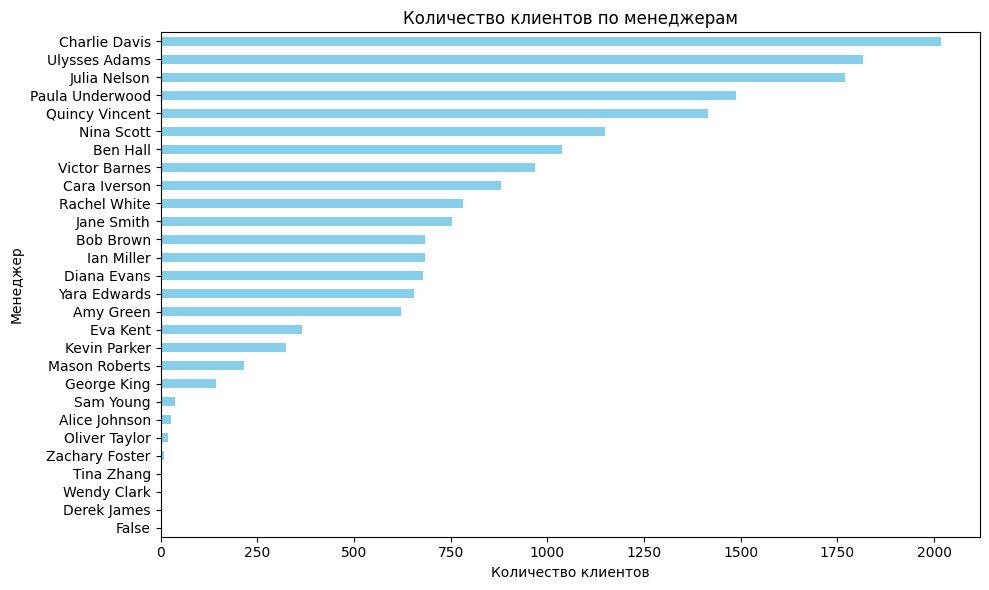

In [ ]:
# Считаем количество клиентов по менеджерам
manager_counts = data_Contacts['Contact Owner Name'].value_counts()

# Строим горизонтальный график
plt.figure(figsize=(10, 6))
manager_counts.plot(kind='barh', color='skyblue')

# Настройки графика
plt.xlabel('Количество клиентов')
plt.ylabel('Менеджер')
plt.title('Количество клиентов по менеджерам')
plt.gca().invert_yaxis()  # Чтобы самый крупный менеджер был сверху
plt.tight_layout()
plt.show()

   Created Month  New Clients
0        2023-06            1
1        2023-07          630
2        2023-08          899
3        2023-09          992
4        2023-10         1458
5        2023-11         1576
6        2023-12         1668
7        2024-01         1992
8        2024-02         1730
9        2024-03         2009
10       2024-04         2535
11       2024-05         1849
12       2024-06         1209


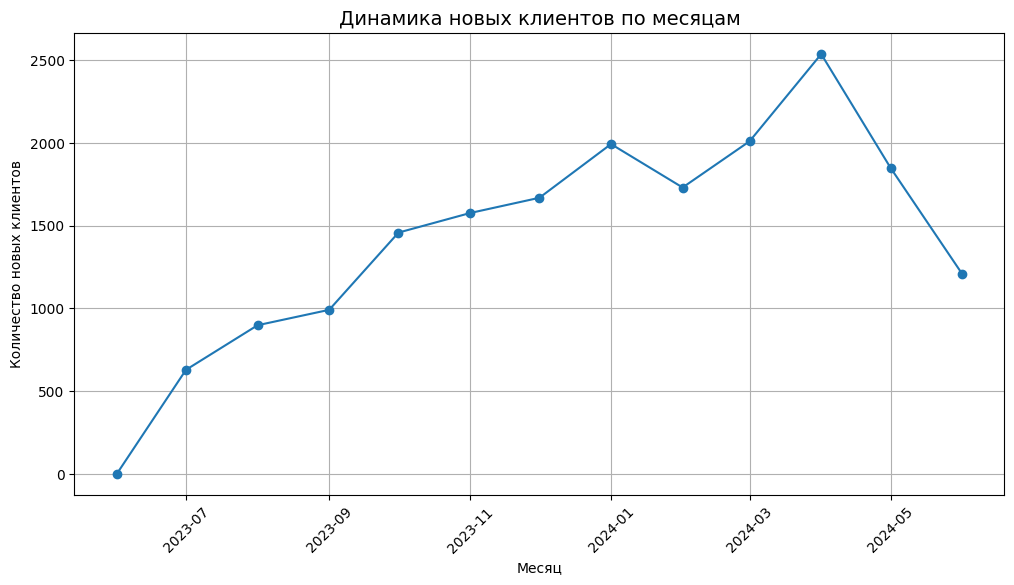

In [ ]:
# Убедимся, что Created Time в datetime
data_Contacts['Created Time'] = pd.to_datetime(data_Contacts['Created Time'])

# Добавляем столбец с месяцем
data_Contacts['Created Month'] = data_Contacts['Created Time'].dt.to_period('M')

# Группируем по месяцам
new_clients_per_month = (
    data_Contacts.groupby('Created Month')['Id']
    .count()
    .reset_index(name='New Clients')
)

print(new_clients_per_month)

# Преобразуем Created Month обратно в datetime
new_clients_per_month['Created Month'] = new_clients_per_month['Created Month'].dt.to_timestamp()

# Строим график
plt.figure(figsize=(12,6))
plt.plot(new_clients_per_month['Created Month'], new_clients_per_month['New Clients'], marker='o')
plt.title("Динамика новых клиентов по месяцам", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Количество новых клиентов")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

   Modified Month  Mod Clients
0         2023-07          318
1         2023-08          622
2         2023-09          730
3         2023-10         1157
4         2023-11         1396
5         2023-12         1407
6         2024-01         1831
7         2024-02         1861
8         2024-03         1917
9         2024-04         2957
10        2024-05         2074
11        2024-06         2278


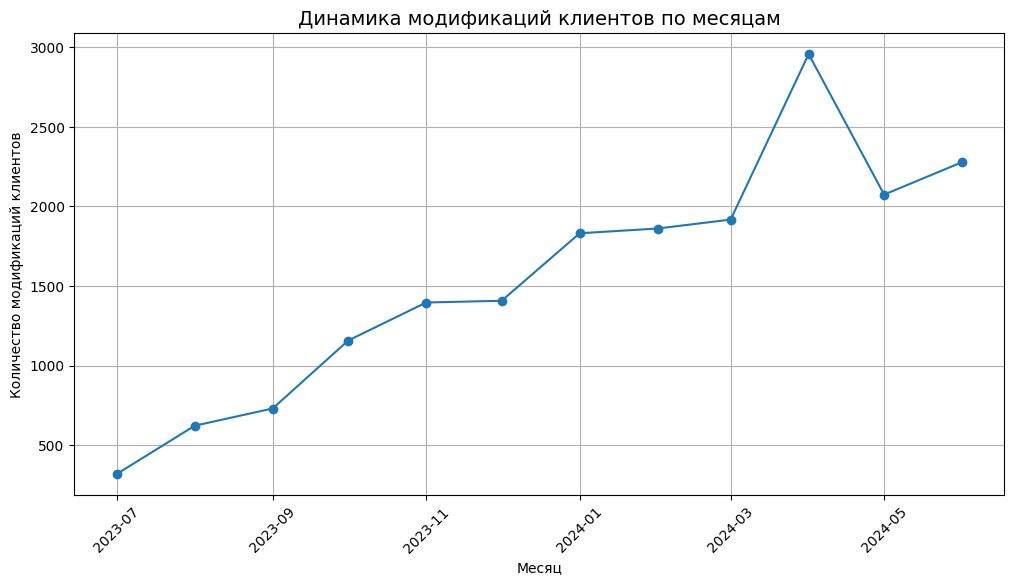

In [ ]:
# Убедимся, что Modified Time в datetime
data_Contacts['Modified Time'] = pd.to_datetime(data_Contacts['Modified Time'])

# Добавляем столбец с месяцем
data_Contacts['Modified Month'] = data_Contacts['Modified Time'].dt.to_period('M')

# Группируем по месяцам
mod_clients_per_month = (
    data_Contacts.groupby('Modified Month')['Id']
    .count()
    .reset_index(name='Mod Clients')
)

print(mod_clients_per_month)

# Преобразуем Created Month обратно в datetime
mod_clients_per_month['Modified Month'] = mod_clients_per_month['Modified Month'].dt.to_timestamp()

# Строим график
plt.figure(figsize=(12,6))
plt.plot(mod_clients_per_month['Modified Month'], mod_clients_per_month['Mod Clients'], marker='o')
plt.title("Динамика модификаций клиентов по месяцам", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Количество модификаций клиентов")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

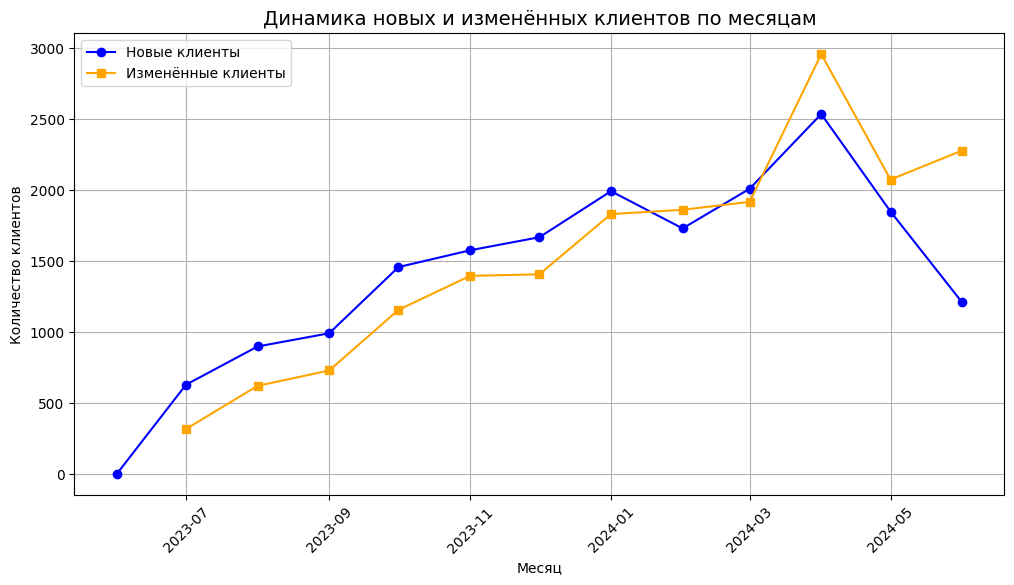

In [ ]:
plt.figure(figsize=(12,6))

# Линия для новых клиентов
plt.plot(new_clients_per_month['Created Month'],
         new_clients_per_month['New Clients'],
         marker='o', color='blue', label='Новые клиенты')

# Линия для изменённых клиентов
plt.plot(mod_clients_per_month['Modified Month'],
         mod_clients_per_month['Mod Clients'],
         marker='s', color='orange', label='Изменённые клиенты')

# Настройка графика
plt.title("Динамика новых и изменённых клиентов по месяцам", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Количество клиентов")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [ ]:


# Считаем разницу в днях между регистрацией и последним изменением
data_Contacts["Last Modified"] = (data_Contacts["Modified Time"] - data_Contacts['Created Time']).dt.days

data_Contacts[["Contact Owner Name", "Modified Time", "Last Modified"]]

,Contact Owner Name,Modified Time,Last Modified
0,Rachel White,2023-12-22 13:34:00,178
1,Charlie Davis,2024-05-21 10:23:00,322
2,Bob Brown,2023-12-21 13:17:00,171
3,Bob Brown,2023-12-29 15:20:00,179
4,Nina Scott,2024-04-16 16:14:00,287
...,...,...,...
18543,Ulysses Adams,2024-06-21 14:11:00,0
18544,Eva Kent,2024-06-21 15:32:00,0
18545,Eva Kent,2024-06-21 12:21:00,0
18546,Yara Edwards,2024-06-21 12:23:00,0


/tmp/ipykernel_1108/3906378815.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stale_contacts_per_manager = stale_contacts.groupby('Contact Owner Name')['Id'].count().reset_index()


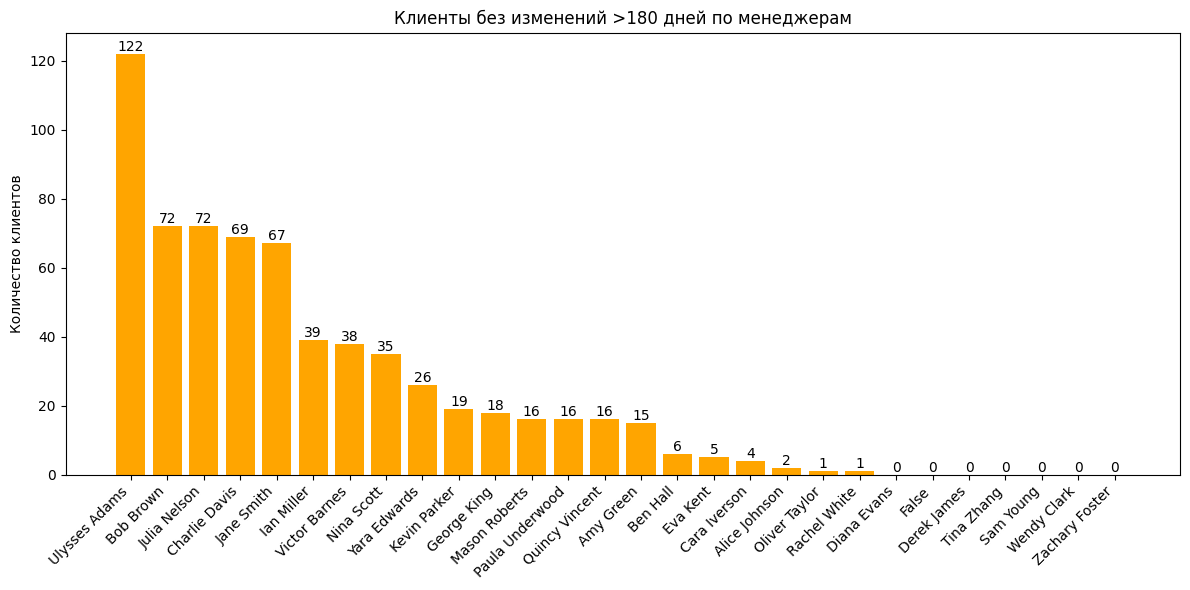

In [ ]:
# не модифицировались больше 180 дней
stale_contacts = data_Contacts[data_Contacts['Last Modified'] > 180]
stale_contacts_per_manager = stale_contacts.groupby('Contact Owner Name')['Id'].count().reset_index()

stale_contacts_per_manager

#график
# Преобразуем менеджеров в строки
stale_contacts_per_manager['Contact Owner Name'] = stale_contacts_per_manager['Contact Owner Name'].astype(str)

# Сортировка по количеству клиентов
stale_contacts_per_manager = stale_contacts_per_manager.sort_values(by='Id', ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(stale_contacts_per_manager['Contact Owner Name'],
               stale_contacts_per_manager['Id'],
               color='orange')

# Подписи над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(int(height)),
             ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество клиентов')
plt.title('Клиенты без изменений >180 дней по менеджерам')
plt.tight_layout()
plt.show()

Существуют клиенты которые были зарегестрированы, но не модифицировались очень долгое время, стоит попробовать связаться с ними еще раз и закрыть если они больше не заинтересованы